In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
df = pd.read_csv('/content/bbc_data.csv')

In [13]:
df.head()

,data,labels
0,Musicians to tackle US red tape Musicians gro...,entertainment
1,"U2s desire to be number one U2, who have won ...",entertainment
2,Rocker Doherty in on-stage fight Rock singer ...,entertainment
3,Snicket tops US box office chart The film ada...,entertainment
4,"Oceans Twelve raids box office Oceans Twelve,...",entertainment


In [14]:
df.shape

(2225, 2)

In [15]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

In [16]:
df['labels'].value_counts()

,count
labels,
sport,511
business,510
politics,417
tech,401
entertainment,386


In [17]:
# 1. Preprocessing

In [18]:
def clean_text(text):
    """
    Comprehensive text preprocessing:
    - Remove HTML tags
    - Remove punctuation and numbers
    - Lowercase conversion
    - Tokenization
    - Stopwords removal
    - Lemmatization
    """
    if not isinstance(text, str):
        return ""

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Lowercase
    text = text.lower()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and short words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back
    cleaned_text = " ".join(tokens)

    # Remove extra spaces
    cleaned_text = re.sub(' +', ' ', cleaned_text).strip()

    return cleaned_text

In [19]:
# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

True

In [20]:
# Apply preprocessing
import nltk
nltk.download('punkt_tab')
df['clean_text'] = df['data'].apply(clean_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [21]:
print(f"Original: {df['data'].iloc[0][:200]}...")
print(f"\nCleaned: {df['clean_text'].iloc[0][:200]}...")

Original: Musicians to tackle US red tape  Musicians groups are to tackle US visa regulations which are blamed for hindering British acts chances of succeeding across the Atlantic.  A singer hoping to perform i...

Cleaned: musician tackle red tape musician group tackle visa regulation blamed hindering british act chance succeeding across atlantic singer hoping perform expect pay simply obtaining visa group including mus...


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
#Task 2 {TF-IDF}Converting the cleaned text to Numerical Vectors
tfidf = TfidfVectorizer(
    max_df=0.85,          # ignore terms that appear in >85% of documents
    min_df=3,             # ignore terms that appear in <3 documents
    max_features=10000,   # limit vocabulary size
    ngram_range=(1,2),    # unigrams + bigrams
    sublinear_tf=True,    # use log scaling for term frequency
    norm='l2'             # L2 normalization
)

X_tfidf = tfidf.fit_transform(df['clean_text'])
print(f" TF-IDF vectorization complete")
print(f"  Shape: {X_tfidf.shape}")
print(f"  Vocabulary size: {len(tfidf.get_feature_names_out())}")
print(f"  Sparsity: {(1.0 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])):.4f}")

 TF-IDF vectorization complete
  Shape: (2225, 10000)
  Vocabulary size: 10000
  Sparsity: 0.9850


In [24]:
#Dimensionality Reduction
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.pipeline import make_pipeline

In [25]:
n_components = 100
svd = TruncatedSVD(n_components=n_components, random_state=42)
normalizer = Normalizer(copy=False)
lsa = make_pipeline(svd, normalizer)

X_lsa = lsa.fit_transform(X_tfidf)

In [26]:
# Task 3  Applying  Clustering Algorithm
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [27]:
#finding optimal number of clusters
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []
inertias = []
K_range = range(3, 11)

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        n_init=20,
        random_state=42
    )
    labels_temp = kmeans_temp.fit_predict(X_lsa)

    sil = silhouette_score(X_lsa, labels_temp)
    cal = calinski_harabasz_score(X_lsa, labels_temp)
    dav = davies_bouldin_score(X_lsa, labels_temp)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_bouldin_scores.append(dav)
    inertias.append(kmeans_temp.inertia_)

    print(f"k={k}: Silhouette={sil:.4f}, Calinski-Harabasz={cal:.2f}, Davies-Bouldin={dav:.4f}")

k=3: Silhouette=0.0550, Calinski-Harabasz=91.63, Davies-Bouldin=4.2402
k=4: Silhouette=0.0650, Calinski-Harabasz=90.27, Davies-Bouldin=3.6281
k=5: Silhouette=0.0769, Calinski-Harabasz=88.12, Davies-Bouldin=3.3480
k=6: Silhouette=0.0810, Calinski-Harabasz=81.26, Davies-Bouldin=3.3015
k=7: Silhouette=0.0831, Calinski-Harabasz=75.62, Davies-Bouldin=3.2039
k=8: Silhouette=0.0853, Calinski-Harabasz=71.02, Davies-Bouldin=3.0390
k=9: Silhouette=0.0907, Calinski-Harabasz=68.99, Davies-Bouldin=2.9226
k=10: Silhouette=0.0860, Calinski-Harabasz=66.62, Davies-Bouldin=3.1067


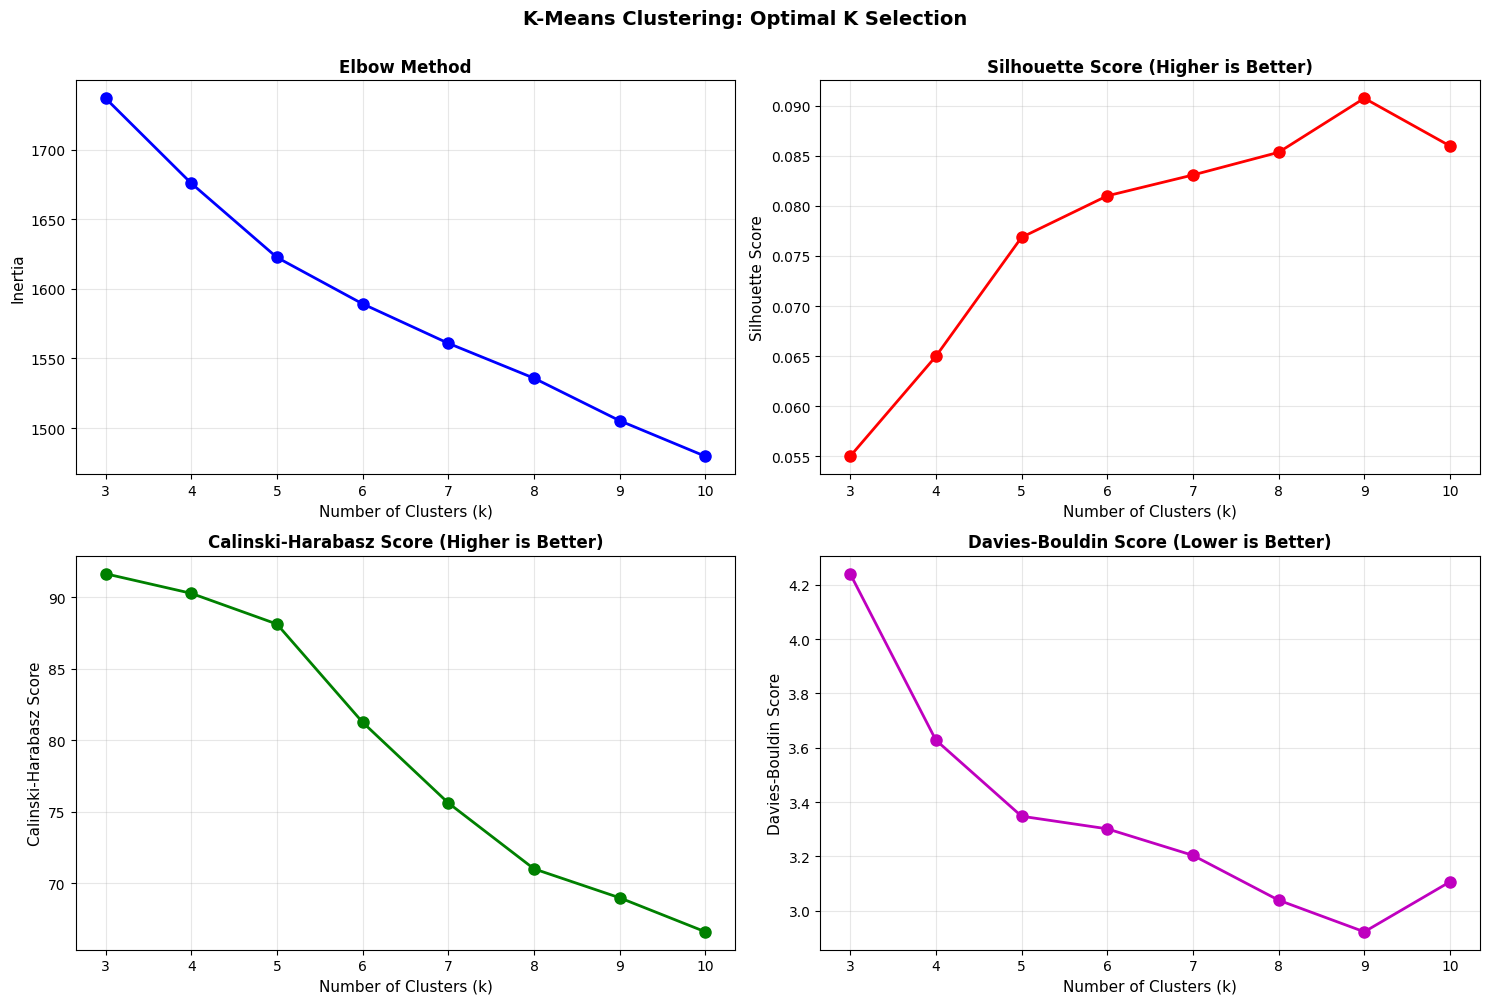

In [28]:
# Plot evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0, 0].set_ylabel('Inertia', fontsize=11)
axes[0, 0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('Silhouette Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(K_range, calinski_scores, 'go-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1, 0].set_ylabel('Calinski-Harabasz Score', fontsize=11)
axes[1, 0].set_title('Calinski-Harabasz Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(K_range, davies_bouldin_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1, 1].set_ylabel('Davies-Bouldin Score', fontsize=11)
axes[1, 1].set_title('Davies-Bouldin Score (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('K-Means Clustering: Optimal K Selection', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [29]:
# Select optimal k
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal k selected: {optimal_k}")

# Final K-Means clustering
kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    max_iter=300,
    n_init=20,
    random_state=42
)
df['kmeans_cluster'] = kmeans.fit_predict(X_lsa)

kmeans_sil = silhouette_score(X_lsa, df['kmeans_cluster'])
kmeans_cal = calinski_harabasz_score(X_lsa, df['kmeans_cluster'])
kmeans_dav = davies_bouldin_score(X_lsa, df['kmeans_cluster'])

print(f"\nK-Means Results (k={optimal_k}):")
print(f"  Silhouette Score: {kmeans_sil:.4f}")
print(f"  Calinski-Harabasz Score: {kmeans_cal:.2f}")
print(f"  Davies-Bouldin Score: {kmeans_dav:.4f}")
print(f"\nCluster distribution:")
print(df['kmeans_cluster'].value_counts().sort_index())


✓ Optimal k selected: 9

K-Means Results (k=9):
  Silhouette Score: 0.0907
  Calinski-Harabasz Score: 68.99
  Davies-Bouldin Score: 2.9226

Cluster distribution:
kmeans_cluster
0    333
1    413
2    424
3     95
4    329
5    166
6    238
7    138
8     89
Name: count, dtype: int64


In [30]:
# 3.2: HIERARCHICAL CLUSTERING
# -------------------------
print(f"\n--- HIERARCHICAL CLUSTERING ---")

hierarchical = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage='ward'
)
df['hierarchical_cluster'] = hierarchical.fit_predict(X_lsa)

hier_sil = silhouette_score(X_lsa, df['hierarchical_cluster'])
hier_cal = calinski_harabasz_score(X_lsa, df['hierarchical_cluster'])
hier_dav = davies_bouldin_score(X_lsa, df['hierarchical_cluster'])

print(f"Hierarchical Clustering Results (k={optimal_k}):")
print(f"  Silhouette Score: {hier_sil:.4f}")
print(f"  Calinski-Harabasz Score: {hier_cal:.2f}")
print(f"  Davies-Bouldin Score: {hier_dav:.4f}")
print(f"\nCluster distribution:")
print(df['hierarchical_cluster'].value_counts().sort_index())


--- HIERARCHICAL CLUSTERING ---
Hierarchical Clustering Results (k=9):
  Silhouette Score: 0.0833
  Calinski-Harabasz Score: 63.55
  Davies-Bouldin Score: 3.0053

Cluster distribution:
hierarchical_cluster
0    545
1    431
2     95
3    183
4    373
5    213
6    183
7     78
8    124
Name: count, dtype: int64


In [31]:
# 3.3: DBSCAN CLUSTERING
# -------------------------
print(f"\n--- DBSCAN CLUSTERING ---")

# DBSCAN requires careful parameter tuning
# We'll test different eps values
from sklearn.neighbors import NearestNeighbors

# Find optimal eps using k-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_lsa)
distances, indices = neighbors_fit.kneighbors(X_lsa)
distances = np.sort(distances[:, -1], axis=0)

# Try multiple eps values
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]
best_dbscan_score = -1
best_eps = eps_values[0]

print("Testing different eps values...")
for eps in eps_values:
    dbscan_temp = DBSCAN(eps=eps, min_samples=5)
    labels_temp = dbscan_temp.fit_predict(X_lsa)

    n_clusters = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
    n_noise = list(labels_temp).count(-1)

    if n_clusters > 1:  # Need at least 2 clusters for silhouette score
        try:
            score = silhouette_score(X_lsa, labels_temp)
            print(f"  eps={eps}: clusters={n_clusters}, noise={n_noise}, silhouette={score:.4f}")

            if score > best_dbscan_score:
                best_dbscan_score = score
                best_eps = eps
        except:
            print(f"  eps={eps}: clusters={n_clusters}, noise={n_noise}, silhouette=N/A")
    else:
        print(f"  eps={eps}: clusters={n_clusters}, noise={n_noise} (too few clusters)")


--- DBSCAN CLUSTERING ---
Testing different eps values...
  eps=0.5: clusters=46, noise=1815, silhouette=-0.0709
  eps=1.0: clusters=1, noise=2 (too few clusters)
  eps=1.5: clusters=1, noise=0 (too few clusters)
  eps=2.0: clusters=1, noise=0 (too few clusters)
  eps=2.5: clusters=1, noise=0 (too few clusters)


In [32]:
# Final DBSCAN with best eps
dbscan = DBSCAN(eps=best_eps, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_lsa)

n_clusters_dbscan = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'] else 0)
n_noise_dbscan = list(df['dbscan_cluster']).count(-1)

print(f"\nDBSCAN Results (eps={best_eps}):")
print(f"  Number of clusters: {n_clusters_dbscan}")
print(f"  Noise points: {n_noise_dbscan}")

if n_clusters_dbscan > 1:
    # Calculate silhouette score excluding noise points
    mask = df['dbscan_cluster'] != -1
    if sum(mask) > 0:
        dbscan_sil = silhouette_score(X_lsa[mask], df['dbscan_cluster'][mask])
        print(f"  Silhouette Score (excl. noise): {dbscan_sil:.4f}")

print(f"\nCluster distribution:")
print(df['dbscan_cluster'].value_counts().sort_index())


DBSCAN Results (eps=0.5):
  Number of clusters: 47
  Noise points: 1815
  Silhouette Score (excl. noise): 0.5614

Cluster distribution:
dbscan_cluster
-1     1815
 0       10
 1       10
 2       29
 3        5
 4        5
 5        6
 6        8
 7       10
 8       22
 9        9
 10       8
 11       5
 12       7
 13       5
 14       8
 15       5
 16       6
 17      14
 18       7
 19       9
 20      30
 21       6
 22       9
 23      10
 24       5
 25       5
 26       5
 27       5
 28       6
 29       5
 30      12
 31       6
 32      11
 33      15
 34       8
 35       8
 36       7
 37       5
 38       5
 39       8
 40      10
 41       7
 42      13
 43       7
 44       8
 45       6
Name: count, dtype: int64


In [33]:
# COMPARISON OF ALGORITHMS
# -------------------------
print(f"\n{'='*70}")
print(f"CLUSTERING ALGORITHMS COMPARISON")
print(f"{'='*70}")
print(f"{'Algorithm':<20} {'Silhouette':<15} {'Calinski-H':<15} {'Davies-B':<15}")
print(f"{'-'*70}")
print(f"{'K-Means':<20} {kmeans_sil:<15.4f} {kmeans_cal:<15.2f} {kmeans_dav:<15.4f}")
print(f"{'Hierarchical':<20} {hier_sil:<15.4f} {hier_cal:<15.2f} {hier_dav:<15.4f}")
if n_clusters_dbscan > 1 and sum(mask) > 0:
    print(f"{'DBSCAN':<20} {dbscan_sil:<15.4f} {'N/A':<15} {'N/A':<15}")
else:
    print(f"{'DBSCAN':<20} {'N/A':<15} {'N/A':<15} {'N/A':<15}")

# Use K-Means for further analysis (typically performs best)
df['cluster'] = df['kmeans_cluster']


CLUSTERING ALGORITHMS COMPARISON
Algorithm            Silhouette      Calinski-H      Davies-B       
----------------------------------------------------------------------
K-Means              0.0907          68.99           2.9226         
Hierarchical         0.0833          63.55           3.0053         
DBSCAN               0.5614          N/A             N/A            


In [35]:
from sklearn.manifold import TSNE


TASK 4: CLUSTER VISUALIZATION (t-SNE)
Computing t-SNE projection...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ t-SNE computation complete


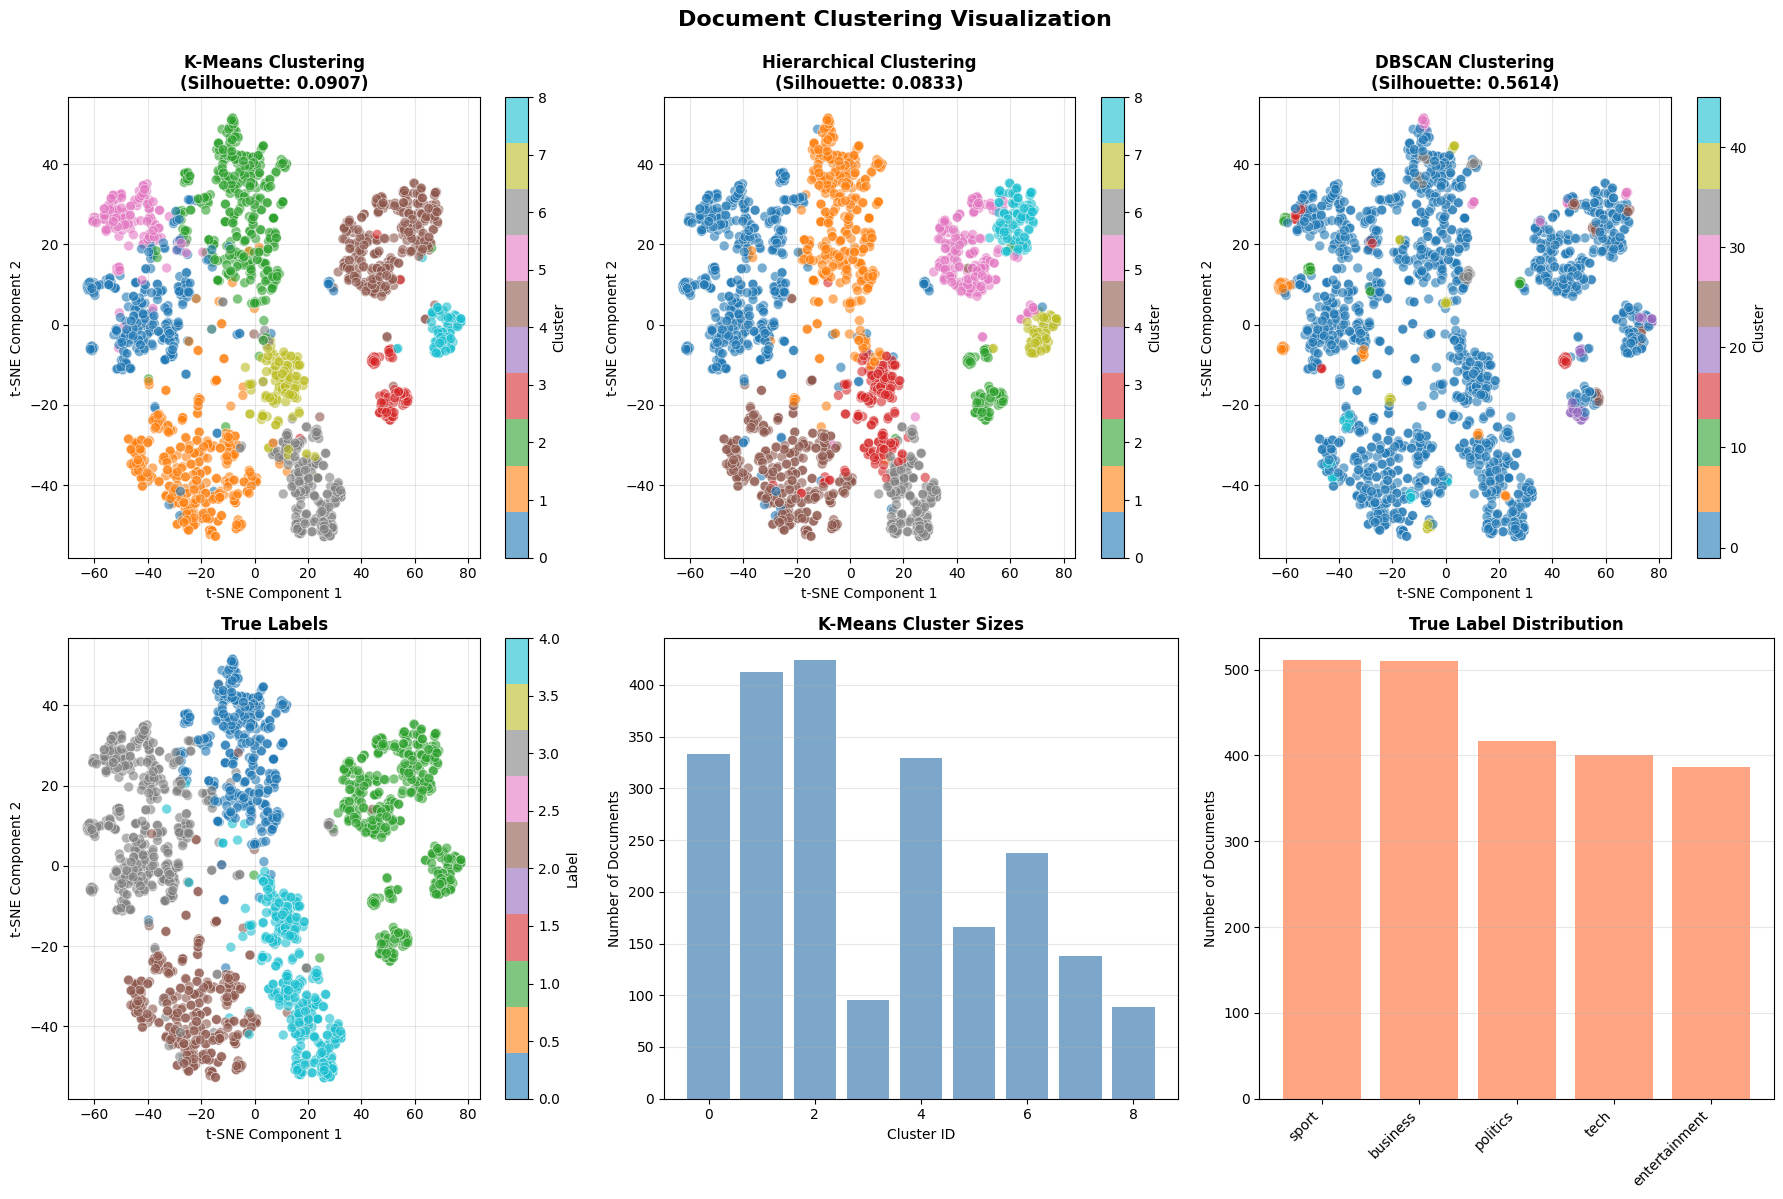

In [36]:
# TASK 4: VISUALIZE CLUSTERS (2D t-SNE plots)
# ========================================================================
print(f"\n{'='*70}")
print(f"TASK 4: CLUSTER VISUALIZATION (t-SNE)")
print(f"{'='*70}")

# Use subset if dataset is large
n_samples = min(len(df), 2000)
if len(df) > n_samples:
    indices = np.random.choice(len(df), n_samples, replace=False)
    X_vis = X_lsa[indices]
    kmeans_vis = df['kmeans_cluster'].iloc[indices]
    hier_vis = df['hierarchical_cluster'].iloc[indices]
    dbscan_vis = df['dbscan_cluster'].iloc[indices]
    labels_vis = df['labels'].iloc[indices] if 'labels' in df.columns else None
else:
    X_vis = X_lsa
    kmeans_vis = df['kmeans_cluster']
    hier_vis = df['hierarchical_cluster']
    dbscan_vis = df['dbscan_cluster']
    labels_vis = df['labels'] if 'labels' in df.columns else None

print("Computing t-SNE projection...")
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter=1000,
    learning_rate=200
)
X_tsne = tsne.fit_transform(X_vis)
print("✓ t-SNE computation complete")

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))

# K-Means t-SNE
ax1 = plt.subplot(2, 3, 1)
scatter1 = ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_vis, cmap='tab10',
                       alpha=0.6, s=50, edgecolors='w', linewidth=0.5)
ax1.set_title(f'K-Means Clustering\n(Silhouette: {kmeans_sil:.4f})',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('t-SNE Component 1')
ax1.set_ylabel('t-SNE Component 2')
plt.colorbar(scatter1, ax=ax1, label='Cluster')
ax1.grid(True, alpha=0.3)

# Hierarchical t-SNE
ax2 = plt.subplot(2, 3, 2)
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=hier_vis, cmap='tab10',
                       alpha=0.6, s=50, edgecolors='w', linewidth=0.5)
ax2.set_title(f'Hierarchical Clustering\n(Silhouette: {hier_sil:.4f})',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('t-SNE Component 1')
ax2.set_ylabel('t-SNE Component 2')
plt.colorbar(scatter2, ax=ax2, label='Cluster')
ax2.grid(True, alpha=0.3)

# DBSCAN t-SNE
ax3 = plt.subplot(2, 3, 3)
scatter3 = ax3.scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan_vis, cmap='tab10',
                       alpha=0.6, s=50, edgecolors='w', linewidth=0.5)
if n_clusters_dbscan > 1 and sum(mask) > 0:
    title = f'DBSCAN Clustering\n(Silhouette: {dbscan_sil:.4f})'
else:
    title = f'DBSCAN Clustering\n(Clusters: {n_clusters_dbscan})'
ax3.set_title(title, fontsize=12, fontweight='bold')
ax3.set_xlabel('t-SNE Component 1')
ax3.set_ylabel('t-SNE Component 2')
plt.colorbar(scatter3, ax=ax3, label='Cluster')
ax3.grid(True, alpha=0.3)

# True labels (if available)
if labels_vis is not None:
    ax4 = plt.subplot(2, 3, 4)
    # Convert labels to numeric for plotting
    label_mapping = {label: idx for idx, label in enumerate(labels_vis.unique())}
    numeric_labels = labels_vis.map(label_mapping)

    scatter4 = ax4.scatter(X_tsne[:, 0], X_tsne[:, 1], c=numeric_labels, cmap='tab10',
                           alpha=0.6, s=50, edgecolors='w', linewidth=0.5)
    ax4.set_title('True Labels', fontsize=12, fontweight='bold')
    ax4.set_xlabel('t-SNE Component 1')
    ax4.set_ylabel('t-SNE Component 2')
    cbar = plt.colorbar(scatter4, ax=ax4)
    cbar.set_label('Label')
    ax4.grid(True, alpha=0.3)

    # Cluster size comparison
    ax5 = plt.subplot(2, 3, 5)
    cluster_sizes = df['kmeans_cluster'].value_counts().sort_index()
    ax5.bar(range(len(cluster_sizes)), cluster_sizes.values, color='steelblue', alpha=0.7)
    ax5.set_xlabel('Cluster ID')
    ax5.set_ylabel('Number of Documents')
    ax5.set_title('K-Means Cluster Sizes', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')

    # True label distribution
    ax6 = plt.subplot(2, 3, 6)
    label_counts = df['labels'].value_counts()
    ax6.bar(range(len(label_counts)), label_counts.values, color='coral', alpha=0.7)
    ax6.set_xticks(range(len(label_counts)))
    ax6.set_xticklabels(label_counts.index, rotation=45, ha='right')
    ax6.set_ylabel('Number of Documents')
    ax6.set_title('True Label Distribution', fontsize=12, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y')

plt.suptitle('Document Clustering Visualization', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



TASK 5: TOPIC IDENTIFICATION & KEYWORD EXTRACTION

CLUSTER 0
Size: 333 documents

Top Keywords:
   1. company
   2. firm
   3. share
   4. said
   5. market
   6. profit
   7. sale
   8. year
   9. deal
  10. executive
  11. business
  12. analyst
  13. financial
  14. chief
  15. stock
  16. would
  17. chief executive
  18. group
  19. new
  20. cost

True Label Distribution:
  business: 322 (96.7%)
  politics: 5 (1.5%)
  tech: 5 (1.5%)
  sport: 1 (0.3%)

Sample Documents:

  Document 1:
  Label: business
  Text: India power shares jump on debut  Shares in Indias largest power producer, National Thermal Power Corp (NTPC) have risen 13% on their stock market debut.  The governments partial sell-off of NTPC is part of a controversial programme to privatise stat...

  Document 2:
  Label: business
  Text: Lacroix label bought by US firm  Luxury goods group LVMH has sold its loss-making Christian Lacroix clothing label to a US investment group.  The Paris-based firm has been shedding no

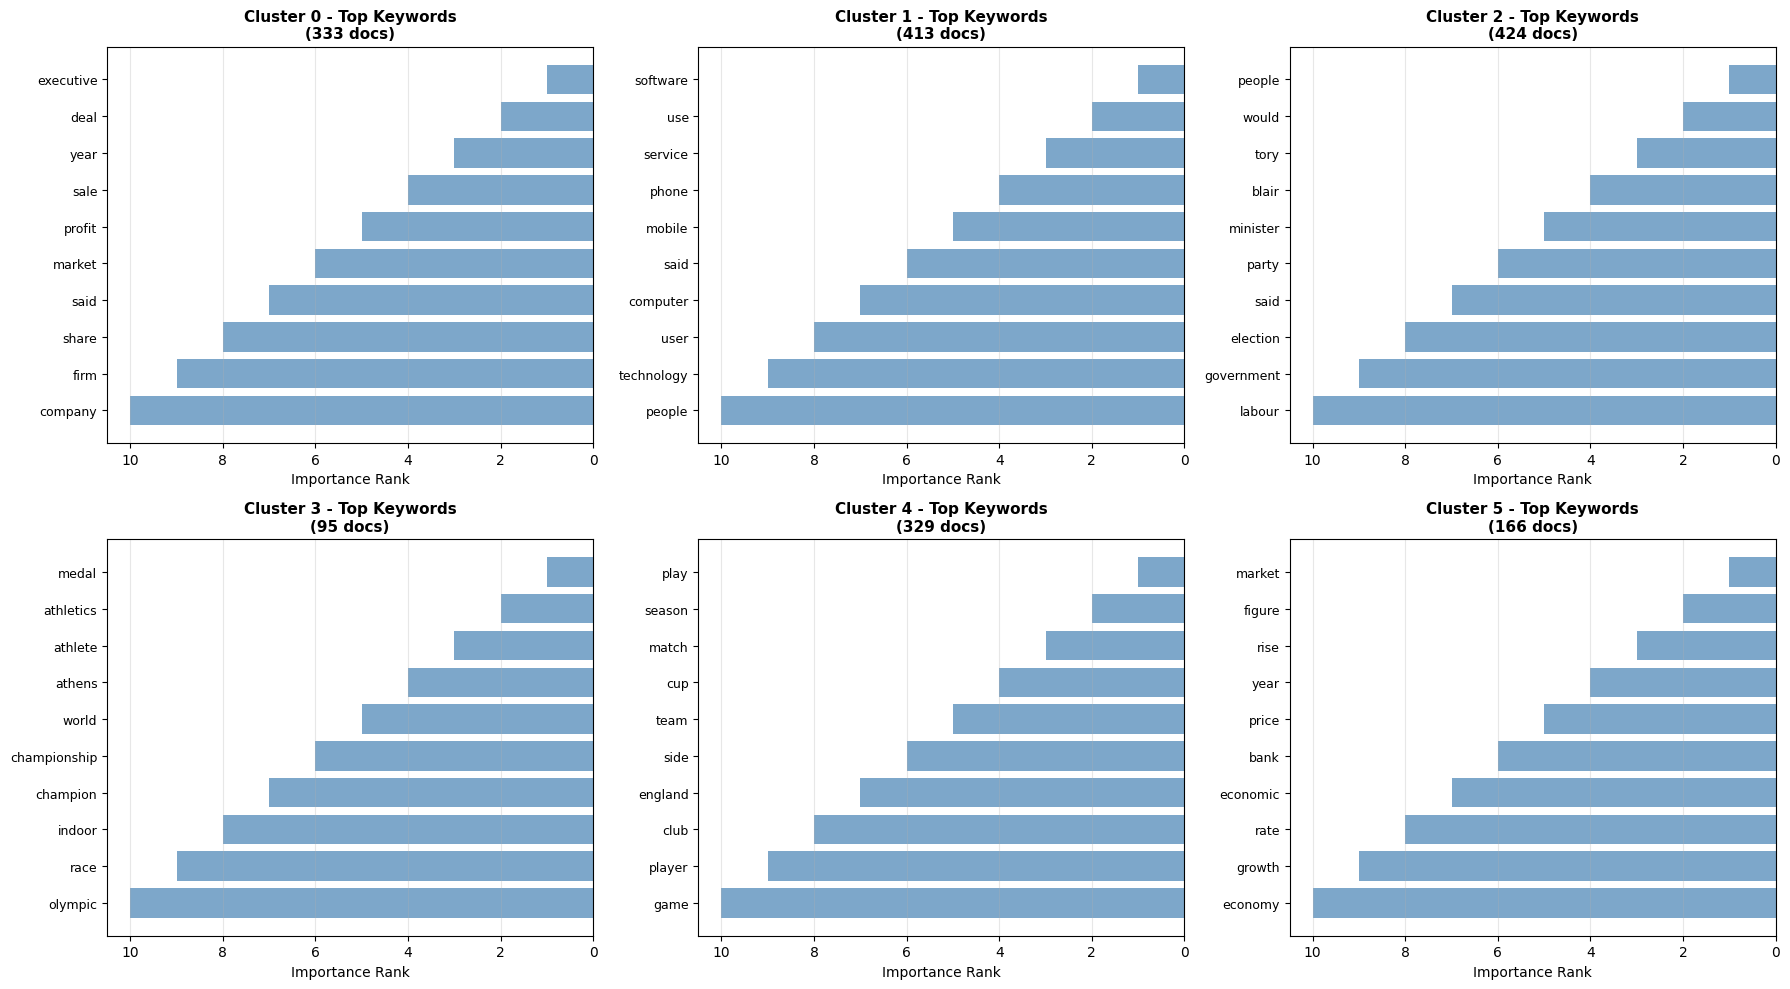

In [37]:
# TASK 5: IDENTIFY MAIN TOPICS/KEYWORDS IN EACH CLUSTER
# ========================================================================
print(f"\n{'='*70}")
print(f"TASK 5: TOPIC IDENTIFICATION & KEYWORD EXTRACTION")
print(f"{'='*70}")

def get_top_keywords_per_cluster(n_terms=15):
    """Extract top keywords for each cluster"""

    # Get cluster centroids in original TF-IDF space
    original_space_centroids = svd.inverse_transform(kmeans.cluster_centers_)
    order_centroids = original_space_centroids.argsort()[:, ::-1]
    terms = tfidf.get_feature_names_out()

    cluster_topics = {}

    for i in range(optimal_k):
        print(f"\n{'='*70}")
        print(f"CLUSTER {i}")
        print(f"{'='*70}")

        # Get top terms
        top_terms = [terms[ind] for ind in order_centroids[i, :n_terms]]
        cluster_topics[i] = top_terms

        print(f"Size: {sum(df['cluster'] == i)} documents")
        print(f"\nTop Keywords:")
        for idx, term in enumerate(top_terms, 1):
            print(f"  {idx:2d}. {term}")

        # Show true label distribution for this cluster
        if 'labels' in df.columns:
            cluster_labels = df[df['cluster'] == i]['labels'].value_counts()
            print(f"\nTrue Label Distribution:")
            for label, count in cluster_labels.items():
                percentage = (count / sum(df['cluster'] == i)) * 100
                print(f"  {label}: {count} ({percentage:.1f}%)")

        # Show sample documents
        print(f"\nSample Documents:")
        cluster_docs = df[df['cluster'] == i]
        for idx, (_, row) in enumerate(cluster_docs.head(2).iterrows(), 1):
            print(f"\n  Document {idx}:")
            if 'labels' in df.columns:
                print(f"  Label: {row['labels']}")
            print(f"  Text: {row['data'][:250]}...")

    return cluster_topics

cluster_keywords = get_top_keywords_per_cluster(n_terms=20)

# -------------------------
# VISUALIZE KEYWORDS
# -------------------------
print(f"\n{'='*70}")
print(f"KEYWORD VISUALIZATION")
print(f"{'='*70}")

# Create word cloud style visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(min(optimal_k, 6)):  # Show up to 6 clusters
    if i < optimal_k:
        keywords = cluster_keywords[i][:10]
        # Create simple bar chart of top keywords
        axes[i].barh(range(len(keywords)), range(len(keywords), 0, -1), color='steelblue', alpha=0.7)
        axes[i].set_yticks(range(len(keywords)))
        axes[i].set_yticklabels(keywords, fontsize=9)
        axes[i].set_xlabel('Importance Rank')
        axes[i].set_title(f'Cluster {i} - Top Keywords\n({sum(df["cluster"] == i)} docs)',
                          fontsize=11, fontweight='bold')
        axes[i].invert_xaxis()
        axes[i].grid(True, alpha=0.3, axis='x')
    else:
        axes[i].axis('off')

plt.tight_layout()
plt.show()



CLUSTER vs TRUE LABEL ANALYSIS

Confusion Matrix:
True Label  business  entertainment  politics  sport  tech
Cluster                                                   
0                322              0         5      1     5
1                 10             11         6      0   386
2                 13              5       404      1     1
3                  0              1         0     94     0
4                  0              0         1    326     2
5                164              1         1      0     0
6                  0            234         0      0     4
7                  1            134         0      0     3
8                  0              0         0     89     0


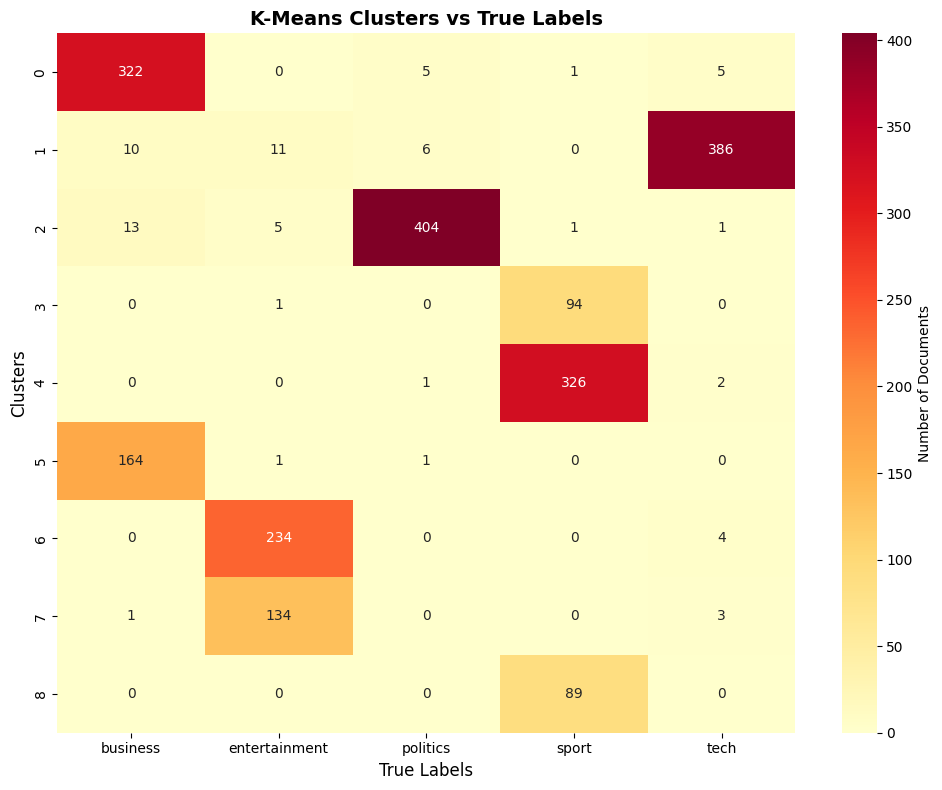

In [38]:
# CLUSTER-LABEL CONFUSION MATRIX
# -------------------------
if 'labels' in df.columns:
    print(f"\n{'='*70}")
    print(f"CLUSTER vs TRUE LABEL ANALYSIS")
    print(f"{'='*70}")

    # Create confusion matrix
    confusion_matrix = pd.crosstab(
        df['kmeans_cluster'],
        df['labels'],
        rownames=['Cluster'],
        colnames=['True Label']
    )

    print("\nConfusion Matrix:")
    print(confusion_matrix)

    # Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        fmt='d',
        cmap='YlOrRd',
        cbar_kws={'label': 'Number of Documents'}
    )
    plt.title('K-Means Clusters vs True Labels', fontsize=14, fontweight='bold')
    plt.xlabel('True Labels', fontsize=12)
    plt.ylabel('Clusters', fontsize=12)
    plt.tight_layout()
    plt.show()

In [39]:
    # Calculate purity
    def cluster_purity(confusion_mat):
        return np.sum(np.max(confusion_mat.values, axis=1)) / np.sum(confusion_mat.values)

    purity = cluster_purity(confusion_matrix)
    print(f"\nCluster Purity: {purity:.4f}")


Cluster Purity: 0.9676


In [40]:
# UI

In [ ]:
# ============================================================================
# GRADIO INTERACTIVE UI - ENHANCED VERSION
# ============================================================================
print(f"\n{'='*70}")
print(f"LAUNCHING GRADIO INTERACTIVE UI")
print(f"{'='*70}")

import gradio as gr

# Generate cluster names based on dominant labels and keywords
def generate_cluster_names():
    """Generate meaningful names for each cluster"""
    cluster_names = {}

    for i in range(optimal_k):
        # Get dominant label if available
        cluster_docs = df[df['cluster'] == i]

        if 'labels' in df.columns and len(cluster_docs) > 0:
            dominant_label = cluster_docs['labels'].value_counts().index[0]
            cluster_names[i] = dominant_label.upper()
        else:
            # Use top keywords if no labels
            top_keyword = cluster_keywords[i][0] if i in cluster_keywords else f"Cluster {i}"
            cluster_names[i] = top_keyword.upper()

    return cluster_names

cluster_names = generate_cluster_names()

def predict_cluster(text, file):
    """Predict cluster for new text input or uploaded file"""

    # Handle file upload
    if file is not None:
        try:
            if file.name.endswith('.txt'):
                with open(file.name, 'r', encoding='utf-8') as f:
                    text = f.read()
            elif file.name.endswith('.csv'):
                df_upload = pd.read_csv(file.name)
                if 'data' in df_upload.columns:
                    text = df_upload['data'].iloc[0]
                else:
                    return "❌ CSV file must contain a 'data' column."
            else:
                return "❌ Please upload a .txt or .csv file."
        except Exception as e:
            return f"❌ Error reading file: {str(e)}"

    # Validate text input
    if not text or text.strip() == "":
        return "⚠️ Please enter some text or upload a file to classify."

    # Clean the input text
    cleaned = clean_text(text)

    if not cleaned or cleaned.strip() == "":
        return "⚠️ Text could not be processed. Please enter valid text with meaningful content."

    # Transform to TF-IDF
    tfidf_vector = tfidf.transform([cleaned])

    # Apply LSA transformation
    lsa_vector = lsa.transform(tfidf_vector)

    # Predict cluster
    cluster_id = kmeans.predict(lsa_vector)[0]
    cluster_name = cluster_names[cluster_id]

    # Get cluster information
    cluster_size = sum(df['cluster'] == cluster_id)
    cluster_docs = df[df['cluster'] == cluster_id]

    # Get top keywords for this cluster
    top_keywords = cluster_keywords[cluster_id][:8]

    # Get label distribution
    label_info = ""
    if 'labels' in df.columns:
        label_dist = cluster_docs['labels'].value_counts()
        if len(label_dist) > 0:
            dominant_label = label_dist.index[0]
            dominant_count = label_dist.iloc[0]
            dominant_pct = (dominant_count / cluster_size) * 100

            label_info = f"""
### 📊 Category Distribution
"""
            for idx, (label, count) in enumerate(label_dist.head(5).items(), 1):
                pct = (count / cluster_size) * 100
                bar_length = int(pct / 5)
                bar = "█" * bar_length + "░" * (20 - bar_length)
                label_info += f"**{label.title()}:** {bar} {pct:.1f}%\n\n"

    # Format output with beautiful styling
    output = f"""
<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 15px; color: white; text-align: center; margin-bottom: 20px;">
    <h1 style="margin: 0; font-size: 2.5em;">🎯 {cluster_name}</h1>
    <p style="margin: 10px 0 0 0; font-size: 1.2em; opacity: 0.9;">Cluster #{cluster_id}</p>
</div>

### 📍 Cluster Overview
**Total Documents:** {cluster_size} articles in this cluster

### 🔑 Key Topics & Keywords
"""

    # Add keywords with styling
    for idx, keyword in enumerate(top_keywords, 1):
        output += f"`{keyword}` "

    output += f"\n\n{label_info}"

    # Add a sample similar article
    if len(cluster_docs) > 0:
        sample_article = cluster_docs['data'].iloc[0][:300]
        output += f"""
### 📰 Similar Article Example
<div style="background-color: #f8f9fa; padding: 15px; border-radius: 10px; border-left: 4px solid #667eea;">
<em>{sample_article}...</em>
</div>
"""

    return output

# Example texts with better diversity
examples = [
    ["Apple announces new iPhone with advanced AI capabilities and improved camera technology for professional photographers."],
    ["The Prime Minister announced new policies regarding healthcare reform in Parliament today during heated debates."],
    ["Manchester United defeated Chelsea 2-1 in a thrilling Premier League match at Old Trafford with a last-minute goal."],
    ["New blockbuster film breaks box office records in its opening weekend with stellar performances from the cast."],
    ["Stock markets surge as major tech companies report better than expected quarterly earnings and revenue growth."],
    ["Scientists discover breakthrough in quantum computing that could revolutionize artificial intelligence development."],
    ["Global leaders meet at climate summit to discuss urgent environmental policies and carbon emission targets."]
]

# Create enhanced Gradio interface with custom CSS
custom_css = """
.gradio-container {
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif !important;
}

.main-header {
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    padding: 40px;
    border-radius: 20px;
    color: white;
    text-align: center;
    margin-bottom: 30px;
    box-shadow: 0 10px 40px rgba(102, 126, 234, 0.3);
}

.stat-box {
    background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%);
    padding: 20px;
    border-radius: 15px;
    color: white;
    text-align: center;
    margin: 10px;
}

#component-0 {
    border: none !important;
}

.primary-btn {
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%) !important;
    border: none !important;
    font-weight: bold !important;
}
"""

with gr.Blocks(title="📄 Document Clustering System", theme=gr.themes.Soft(), css=custom_css) as demo:

    # Header
    gr.HTML("""
    <div class="main-header">
        <h1 style="margin: 0; font-size: 3em; text-shadow: 2px 2px 4px rgba(0,0,0,0.2);">📄 Document Clustering System</h1>
        <p style="margin: 15px 0 0 0; font-size: 1.3em; opacity: 0.95;">Intelligent News Article Classification using AI</p>
        <p style="margin: 10px 0 0 0; opacity: 0.8;">Trained on 2,225 BBC News Articles • {} Clusters • K-Means Algorithm</p>
    </div>
    """.format(optimal_k))

    # Stats row
    with gr.Row():
        with gr.Column(scale=1):
            gr.HTML(f"""
            <div class="stat-box">
                <h2 style="margin: 0; font-size: 2.5em;">🎯</h2>
                <h3 style="margin: 10px 0 5px 0;">{optimal_k}</h3>
                <p style="margin: 0; opacity: 0.9;">Clusters</p>
            </div>
            """)
        with gr.Column(scale=1):
            gr.HTML(f"""
            <div class="stat-box">
                <h2 style="margin: 0; font-size: 2.5em;">📚</h2>
                <h3 style="margin: 10px 0 5px 0;">2,225</h3>
                <p style="margin: 0; opacity: 0.9;">Documents</p>
            </div>
            """)
        with gr.Column(scale=1):
            gr.HTML(f"""
            <div class="stat-box">
                <h2 style="margin: 0; font-size: 2.5em;">🔤</h2>
                <h3 style="margin: 10px 0 5px 0;">{len(tfidf.get_feature_names_out())}</h3>
                <p style="margin: 0; opacity: 0.9;">Features</p>
            </div>
            """)

    gr.Markdown("---")

    # Main interface
    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 📝 Input Your Document")

            # Tabs for text input and file upload
            with gr.Tabs():
                with gr.Tab("✍️ Type Text"):
                    input_text = gr.Textbox(
                        label="Enter Article Text",
                        placeholder="Paste your news article here...\n\nExample: 'The championship game ended with a dramatic victory...'",
                        lines=12,
                        max_lines=15
                    )

                with gr.Tab("📁 Upload File"):
                    input_file = gr.File(
                        label="Upload Document",
                        file_types=[".txt", ".csv"],
                        type="filepath"
                    )
                    gr.Markdown("*Supported formats: .txt, .csv (with 'data' column)*")

            with gr.Row():
                predict_btn = gr.Button("🔍 Classify Document", variant="primary", size="lg", elem_classes="primary-btn")
                clear_btn = gr.Button("🗑️ Clear All", size="lg")

        with gr.Column(scale=1):
            gr.Markdown("### 🎯 Classification Results")
            output_text = gr.Markdown(
                value="*Results will appear here after classification...*",
                label="Results"
            )

    gr.Markdown("---")

    # Examples section with better styling
    gr.Markdown("### 💡 Try These Example Articles")
    gr.Examples(
        examples=examples,
        inputs=input_text,
        label=None,
        examples_per_page=7
    )

    # Cluster overview
    with gr.Accordion("🗂️ View All Clusters", open=False):
        cluster_overview = "### Available Clusters\n\n"
        for i in range(optimal_k):
            cluster_size = sum(df['cluster'] == i)
            keywords = ", ".join(cluster_keywords[i][:5])
            cluster_overview += f"**{cluster_names[i]} (Cluster {i})** • {cluster_size} docs • *{keywords}*\n\n"
        gr.Markdown(cluster_overview)

    # About section
    with gr.Accordion("ℹ️ About This System", open=False):
        gr.Markdown(f"""
        ### How It Works

        This intelligent classification system uses advanced machine learning techniques to automatically categorize news articles:

        1. **Text Preprocessing** - Cleans and normalizes the input text
        2. **Feature Extraction** - Converts text to numerical features using TF-IDF
        3. **Dimensionality Reduction** - Reduces features to {n_components} components using LSA
        4. **Clustering** - Assigns articles to one of {optimal_k} clusters using K-Means

        ### Dataset
        - **Source:** BBC News Articles
        - **Size:** 2,225 documents
        - **Categories:** Business, Entertainment, Politics, Sport, Technology

        ### Technologies
        - Scikit-learn for ML algorithms
        - NLTK for text preprocessing
        - TF-IDF for feature extraction
        - K-Means clustering with k-means++ initialization
        """)

    # Event handlers
    predict_btn.click(
        fn=predict_cluster,
        inputs=[input_text, input_file],
        outputs=output_text
    )

    clear_btn.click(
        fn=lambda: ("", None, "*Results will appear here after classification...*"),
        inputs=None,
        outputs=[input_text, input_file, output_text]
    )

# Launch the interface
print("🚀 Launching Gradio interface...")
demo.launch(share=True, debug=True)
print("✓ Interface is ready!")


LAUNCHING GRADIO INTERACTIVE UI


/tmp/ipython-input-2942443800.py:174: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="📄 Document Clustering System", theme=gr.themes.Soft(), css=custom_css) as demo:
/tmp/ipython-input-2942443800.py:174: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(title="📄 Document Clustering System", theme=gr.themes.Soft(), css=custom_css) as demo:


🚀 Launching Gradio interface...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b654a64866b14a58d0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
